# Dropping Buoys - Repeated Relativistic Boosts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lookbusy1344/Relativity/blob/main/Python/Dropping_buoys.ipynb)

A spaceship leaves Earth and accelerates to $0.5c$. The crew drop a buoy - a small beacon that drifts freely in space - and immediately accelerate to $0.5c$ **relative to that buoy**. They drop another buoy and do it again. And again.

From inside the ship, every boost is *identical*. The crew always accelerate to $0.5c$ relative to their immediate surroundings. There is no sense of accumulation, no extra effort required, no alarm that sounds. The laws of physics are the same in every inertial frame, so each boost looks and feels exactly like the first.

The buoys form a chain of reference frames, each moving at $0.5c$ relative to its neighbour:

$$\text{Earth} \xrightarrow{\;0.5c\;} \text{Buoy 1} \xrightarrow{\;0.5c\;} \text{Buoy 2} \xrightarrow{\;0.5c\;} \cdots \xrightarrow{\;0.5c\;} \text{Buoy } 23$$

Each arrow is a *relative* velocity between adjacent frames. The question is: what does Earth observe?

In [17]:
# Download relativity_lib.py if not present (important for Google Colab)
import os

if not os.path.exists("relativity_lib.py"):
    !wget -q https://raw.githubusercontent.com/lookbusy1344/Relativity/main/Python/relativity_lib.py

import matplotlib.pyplot as plt
import mpmath as mp
import relativity_lib as rl
from prettytable import PrettyTable, TableStyle
from IPython.display import Markdown

rl.configure(100)  # 100 decimal places of precision throughout

NUM_BUOYS = 23
BOOST_FRACTION = rl.ensure("0.5")  # 0.5c per boost, in proper frame
BOOST_VELOCITY = rl.c * BOOST_FRACTION  # in m/s
GALAXY_LY = rl.ensure("100000")  # Milky Way diameter, light-years

print(f"Boost per step (proper frame): {float(BOOST_FRACTION)}c")
print(f"Number of buoys to drop:       {NUM_BUOYS}")

Boost per step (proper frame): 0.5c
Number of buoys to drop:       23


## The crew's point of view

At every stage the ship's crew repeat the same manoeuver:

1. Check speed relative to the last dropped buoy: zero - we are momentarily at rest in that frame
2. Fire engines, accelerate to $0.5c$ relative to that buoy
3. Drop the next buoy, which drifts away at $0.5c$ behind us
4. Repeat

Nothing changes from one boost to the next. The crew never experience anything that could tell them they are doing something different or harder than before. This is a direct consequence of the *equivalence of inertial frames*: there is no experiment you can perform inside the ship to determine your absolute speed.

## What Earth sees - relativistic velocity addition

Earth's perspective is more constrained. Velocities do not add naively across inertial frames. The correct formula is:

$$v_{\text{combined}} = \frac{v_1 + v_2}{1 + \dfrac{v_1 v_2}{c^2}} \tag{1}$$

Each time the crew boost by $0.5c$ in their current frame, Earth applies equation (1) to find the new coordinate velocity. The denominator keeps the result strictly below $c$, no matter how many boosts occur.

In [18]:
# Build up Earth-frame velocity, one boost at a time.
# Each boost adds 0.5c in the current proper frame; rl.add_velocities() applies equation (1).

earth_frame_velocities = []
current_vel = rl.ensure("0")  # ship starts at rest relative to Earth

for _ in range(NUM_BUOYS):
    current_vel = rl.add_velocities(current_vel, BOOST_VELOCITY)
    earth_frame_velocities.append(current_vel)

earth_frame_fractions = [v / rl.c for v in earth_frame_velocities]

# What naive Newtonian physics would predict
naive_final_c = BOOST_FRACTION * NUM_BUOYS

print(f"Newtonian (wrong):   {float(naive_final_c):.1f}c  - faster than light!")
print(
    f"Relativistic:        {rl.format_mpf_significant(earth_frame_fractions[-1], 6, '9')}c"
)

Newtonian (wrong):   11.5c  - faster than light!
Relativistic:        0.9999999999787557c


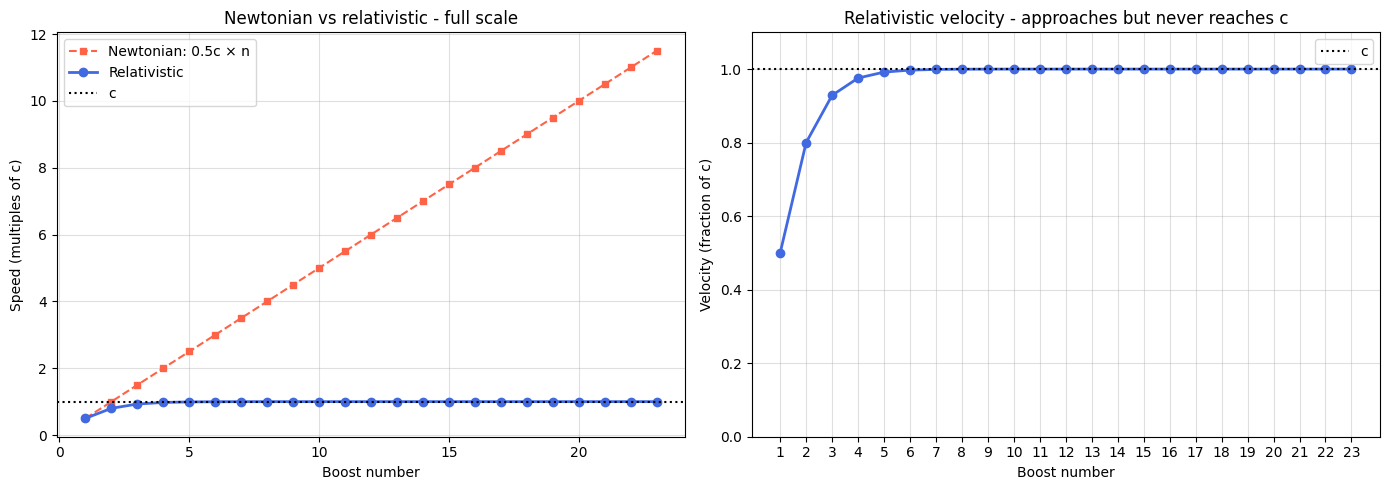

In [19]:
boost_nums = list(range(1, NUM_BUOYS + 1))
earth_fracs_float = [float(f) for f in earth_frame_fractions]
naive_fracs = [float(BOOST_FRACTION) * n for n in boost_nums]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: full scale - Newtonian vs relativistic
ax1.plot(
    boost_nums,
    naive_fracs,
    "s--",
    color="tomato",
    linewidth=1.5,
    markersize=5,
    label="Newtonian: 0.5c × n",
)
ax1.plot(
    boost_nums,
    earth_fracs_float,
    "o-",
    color="royalblue",
    linewidth=2,
    markersize=6,
    label="Relativistic",
)
ax1.axhline(y=1.0, color="black", linestyle=":", linewidth=1.5, label="c")
ax1.set_xlabel("Boost number")
ax1.set_ylabel("Speed (multiples of c)")
ax1.set_title("Newtonian vs relativistic - full scale")
ax1.legend()
ax1.grid(True, alpha=0.4)

# Right: zoom in on the relativistic curve
ax2.plot(
    boost_nums, earth_fracs_float, "o-", color="royalblue", linewidth=2, markersize=6
)
ax2.axhline(y=1.0, color="black", linestyle=":", linewidth=1.5, label="c")
ax2.set_xlabel("Boost number")
ax2.set_ylabel("Velocity (fraction of c)")
ax2.set_title("Relativistic velocity - approaches but never reaches c")
ax2.legend()
ax2.grid(True, alpha=0.4)
ax2.set_xticks(boost_nums)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show();

The left panel makes the contrast stark. Newtonian physics has the ship exceeding $c$ after just two boosts. The relativistic curve flattens instead, each successive boost contributing less and less to the coordinate velocity as seen from Earth.

## Rapidity - why each boost truly is identical

*Rapidity* $\phi$ is the natural measure of relativistic motion. It is defined as:

$$\phi = \tanh^{-1}\!\left(\frac{v}{c}\right) \tag{2}$$

Unlike coordinate velocity, rapidities add *linearly*. When you boost by $0.5c$ in your current frame you always add exactly $\phi_{0.5c}$ to your rapidity - regardless of how fast you were already going. After $n$ identical boosts:

$$\phi_n = n \cdot \phi_{0.5c} \tag{3}$$

This is the mathematical confirmation of what the crew experience: each boost is genuinely the same operation. The ship's rapidity is a running total that grows at a constant rate, one step per buoy. To recover the coordinate velocity for a given observer, convert back via:

$$v = c \cdot \tanh(\phi_n) \tag{4}$$

Because $\tanh$ maps all of $\mathbb{R}$ into $(-1, 1)$, rapidity can grow without bound - perform ten thousand boosts if you like - yet the coordinate velocity asymptotically approaches $c$ and never reaches it.

In [20]:
# Rapidity of a single 0.5c boost
rap_single = rl.rapidity_from_velocity(BOOST_VELOCITY)
print(f"Rapidity of one 0.5c boost: {float(rap_single):.6f}")
print(f"(Each subsequent boost adds exactly this much - no accumulation, no friction)")
print()

# Total rapidity and velocity after each boost, via simple multiplication
rapidities = [rap_single * rl.ensure(str(n)) for n in range(1, NUM_BUOYS + 1)]
velocities_from_rap = [rl.velocity_from_rapidity(r) for r in rapidities]
fractions_from_rap = [v / rl.c for v in velocities_from_rap]

# Verify both methods agree to many decimal places
max_diff = max(
    abs(float(f1 - f2)) for f1, f2 in zip(earth_frame_fractions, fractions_from_rap)
)
print(f"Max difference vs velocity-addition method: {max_diff:.2e}  (rounding only)")

Rapidity of one 0.5c boost: 0.549306
(Each subsequent boost adds exactly this much - no accumulation, no friction)

Max difference vs velocity-addition method: 1.43e-101  (rounding only)


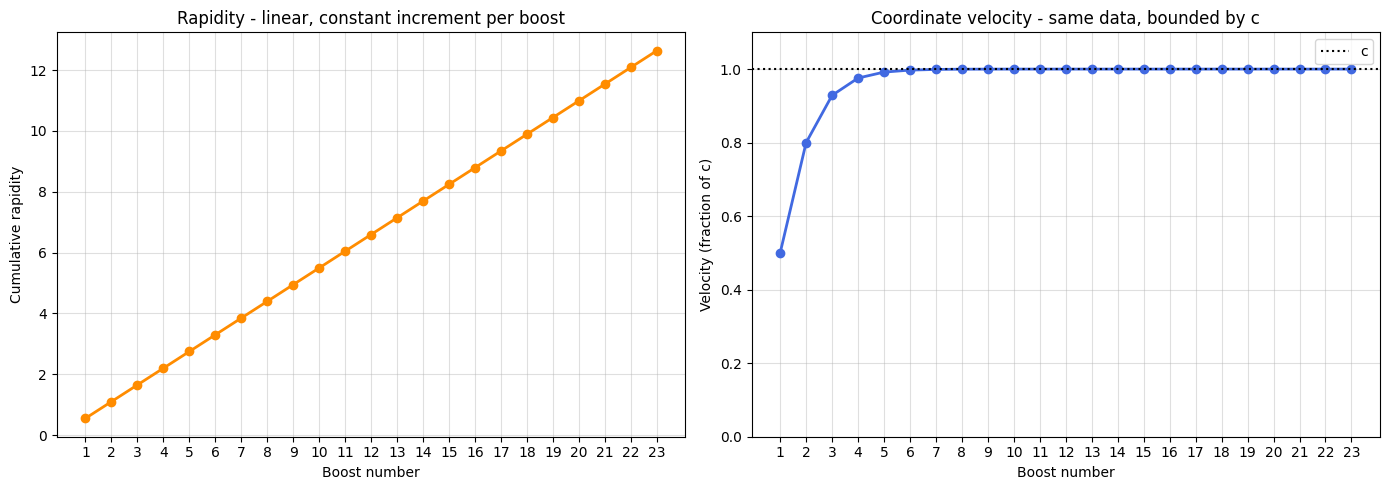

In [21]:
rapidities_float = [float(r) for r in rapidities]
fracs_float = [float(f) for f in fractions_from_rap]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: rapidity grows linearly - each boost is identical
ax1.plot(
    boost_nums, rapidities_float, "o-", color="darkorange", linewidth=2, markersize=6
)
ax1.set_xlabel("Boost number")
ax1.set_ylabel("Cumulative rapidity")
ax1.set_title("Rapidity - linear, constant increment per boost")
ax1.grid(True, alpha=0.4)
ax1.set_xticks(boost_nums)

# Right: velocity curves toward c
ax2.plot(boost_nums, fracs_float, "o-", color="royalblue", linewidth=2, markersize=6)
ax2.axhline(y=1.0, color="black", linestyle=":", linewidth=1.5, label="c")
ax2.set_xlabel("Boost number")
ax2.set_ylabel("Velocity (fraction of c)")
ax2.set_title("Coordinate velocity - same data, bounded by c")
ax2.legend()
ax2.grid(True, alpha=0.4)
ax2.set_xticks(boost_nums)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.show();

The left panel is the crew's reality: a straight line, constant slope, same boost every time. The right panel is what an external observer computes: the same data, compressed by the $\tanh$ function into a curve that never quite touches $c$.

Both panels describe the same physical events. The difference is only in which coordinate system you use to describe them.

## Length contraction - the galaxy from each buoy's frame

Every buoy is at rest in its own inertial frame. From buoy $n$'s perspective, the Milky Way is rushing past at the buoy's coordinate velocity $v_n$. Distances in the direction of motion are contracted by the Lorentz factor:

$$\gamma = \frac{1}{\sqrt{1 - v^2/c^2}} \tag{5}$$

The galaxy's 100,000 light-year width shrinks to:

$$L_{\text{buoy}} = \frac{L_0}{\gamma} \tag{6}$$

Each successive buoy has a higher $\gamma$ and sees a more compressed galaxy. By the time we reach buoy 23, the Milky Way is a thin disc from that frame's point of view.

## Table of all 23 boosts

In [22]:
table = PrettyTable(
    [
        "Buoy",
        "Rapidity",
        "Velocity (c)",
        "Lorentz γ",
        "Galaxy width (ly)",
        "Transit time (yr)",
    ]
)
table.set_style(TableStyle.MARKDOWN)
table.align = "r"

for n in range(1, NUM_BUOYS + 1):
    rapidity = rap_single * rl.ensure(str(n))
    velocity = rl.velocity_from_rapidity(rapidity)
    fraction = velocity / rl.c
    gamma = rl.lorentz_factor(velocity)
    galaxy_width = GALAXY_LY / gamma
    # Proper time for this buoy to cross the contracted galaxy at its velocity
    transit_years = galaxy_width / fraction

    table.add_row(
        [
            str(n),
            rl.format_mpf_significant(rapidity, 4),
            rl.format_mpf_significant(fraction, 4, "9"),
            rl.format_mpf(gamma, 2),
            rl.format_mpf(galaxy_width, 1),
            rl.format_mpf(transit_years, 1),
        ]
    )

display(Markdown(table.get_string()));

| Buoy | Rapidity |     Velocity (c) |  Lorentz γ | Galaxy width (ly) | Transit time (yr) |
|----: |--------: |----------------: |----------: |-----------------: |-----------------: |
|    1 |   0.5493 |              0.5 |       1.15 |          86,602.5 |         173,205.0 |
|    2 |  1.09861 |              0.8 |       1.66 |          60,000.0 |          75,000.0 |
|    3 |   1.6479 |          0.92857 |       2.69 |          37,115.3 |          39,970.4 |
|    4 |   2.1972 |          0.97560 |       4.55 |          21,951.2 |          22,500.0 |
|    5 |   2.7465 |         0.991803 |       7.82 |          12,777.4 |          12,883.0 |
|    6 |   3.2958 |         0.997260 |      13.51 |           7,397.2 |           7,417.5 |
|    7 |   3.8451 |        0.9990859 |      23.39 |           4,274.7 |           4,278.6 |
|    8 |   4.3944 |        0.9996952 |      40.50 |           2,468.7 |           2,469.5 |
|    9 |   4.9437 |        0.9998983 |      70.15 |           1,425.4 |           1,425.6 |
|   10 |   5.4930 |       0.99996613 |     121.50 |             823.0 |             823.0 |
|   11 |  6.04236 |       0.99998871 |     210.44 |             475.1 |             475.1 |
|   12 |   6.5916 |      0.999996236 |     364.50 |             274.3 |             274.3 |
|   13 |   7.1409 |      0.999998745 |     631.33 |             158.3 |             158.3 |
|   14 |   7.6902 |     0.9999995818 |   1,093.50 |              91.4 |              91.4 |
|   15 |   8.2395 |     0.9999998606 |   1,893.99 |              52.7 |              52.7 |
|   16 |   8.7888 |    0.99999995353 |   3,280.50 |              30.4 |              30.4 |
|   17 |   9.3382 |    0.99999998451 |   5,681.99 |              17.5 |              17.5 |
|   18 |   9.8875 |   0.999999994837 |   9,841.50 |              10.1 |              10.1 |
|   19 |  10.4368 |   0.999999998279 |  17,045.97 |               5.8 |               5.8 |
|   20 |  10.9861 |  0.9999999994264 |  29,524.50 |               3.3 |               3.3 |
|   21 |  11.5354 |  0.9999999998088 |  51,137.93 |               1.9 |               1.9 |
|   22 | 12.08473 | 0.99999999993626 |  88,573.50 |               1.1 |               1.1 |
|   23 |  12.6340 | 0.99999999997875 | 153,413.80 |               0.6 |               0.6 |

## The final state - summary

In [23]:
# Final state after all 23 boosts, computed directly via rapidity
tot_rap = rap_single * rl.ensure(str(NUM_BUOYS))
tot_vel = rl.velocity_from_rapidity(tot_rap)
tot_fraction = tot_vel / rl.c
lorentz = rl.lorentz_factor(tot_vel)
galaxy_contracted = GALAXY_LY / lorentz

print(f"Total rapidity after {NUM_BUOYS} boosts:    {float(tot_rap):.6f}")
print(
    f"Velocity in Earth frame:         {rl.format_mpf_significant(tot_fraction, 8, '9')}c"
)
print(f"Lorentz factor γ:                {rl.format_mpf(lorentz, 2)}")
print(
    f"Galaxy width in buoy-23 frame:   {rl.format_mpf(galaxy_contracted, 2)} light-years"
)

Total rapidity after 23 boosts:    12.634041
Velocity in Earth frame:         0.999999999978755763c
Lorentz factor γ:                153,413.80
Galaxy width in buoy-23 frame:   0.65 light-years


## Energy, relativistic mass, and the rocket equation

Every discussion of relativistic travel eventually hits the same objection: *what about the fuel?* Each boost requires energy, and that energy has to come from somewhere.

### Relativistic energy

The total energy of a moving object is:

$$E = \gamma m c^2 \tag{7}$$

At rest ($\gamma = 1$) this reduces to the famous $E = mc^2$. In motion, $\gamma > 1$ and the total energy is higher. After 23 boosts our ship has $\gamma \approx 153{,}414$, so from Earth's perspective it carries enormous energy - even for a small final payload mass.

The term *relativistic mass* ($\gamma m$) is sometimes used for this, though modern physics prefers to keep mass as a Lorentz invariant (rest mass $m$) and track the energy separately. The physics is identical either way.

### The rocket equation

To accelerate, the ship must expel mass as exhaust. The relativistic Tsiolkovsky rocket equation for a *photon drive* - the theoretical optimum, where exhaust is pure radiation at $v_{\text{exhaust}} = c$ - gives a mass ratio per boost of:

$$\frac{m_{\text{after}}}{m_{\text{before}}} = \sqrt{\frac{1 - \beta}{1 + \beta}} \tag{8}$$

For $\beta = 0.5$ this is $\frac{1}{\sqrt{3}} \approx 0.577$, meaning each boost consumes roughly 42% of the ship's mass as fuel. A real rocket with exhaust velocity $v_e < c$ would have a worse mass ratio still.

### Why later boosts get cheaper

Here is the counterintuitive result. Equation (8) says the ship retains the same *fraction* of its mass after each boost, regardless of boost number. Since the ship is lighter after every burn, the *absolute* fuel mass burned decreases with each successive boost.

Boost 1 is the most expensive. Boost 23 is the cheapest. The mass budget front-loads all the hard work.

The challenge of the rocket equation is not that later boosts are harder - it is the catastrophic initial mass ratio required to carry enough fuel for *all* of them. But once underway, each individual boost is less demanding than the one before.

In [24]:
# Photon drive mass ratio per 0.5c boost: sqrt((1-β)/(1+β))
mass_ratio = mp.sqrt((rl.one - BOOST_FRACTION) / (rl.one + BOOST_FRACTION))
fuel_fraction = rl.one - mass_ratio  # fraction of ship mass burned per boost

print(f"Mass ratio per boost (photon drive): {float(mass_ratio):.6f}")
print(
    f"Fuel consumed per boost:             {float(fuel_fraction) * 100:.2f}% of ship mass"
)
print()

# To deliver 1 kg of payload after all 23 boosts, how much did we start with?
payload_kg = rl.ensure("1")
initial_mass = payload_kg / (mass_ratio**NUM_BUOYS)

print(f"To deliver {float(payload_kg):.0f} kg of payload after {NUM_BUOYS} boosts:")
print(f"  Required initial mass: {rl.format_mpf(initial_mass, 1)} kg")
print(f"  Overall mass ratio:    {rl.format_mpf(initial_mass / payload_kg, 0)}:1")
print()

# Absolute fuel burned per boost (normalised to initial_mass = 1)
remaining = [float(mass_ratio**n) for n in range(NUM_BUOYS + 1)]
fuel_each = [remaining[n] - remaining[n + 1] for n in range(NUM_BUOYS)]

print(f"Boost  1 burns {fuel_each[0]:.4f} × initial mass")
print(f"Boost 23 burns {fuel_each[-1]:.2e} × initial mass")
print(f"Boost 23 costs {fuel_each[-1] / fuel_each[0] * 100:.4f}% as much as boost 1")

Mass ratio per boost (photon drive): 0.577350
Fuel consumed per boost:             42.26% of ship mass

To deliver 1 kg of payload after 23 boosts:
  Required initial mass: 306,827.6 kg
  Overall mass ratio:    306,827:1

Boost  1 burns 0.4226 × initial mass
Boost 23 burns 2.39e-06 × initial mass
Boost 23 costs 0.0006% as much as boost 1


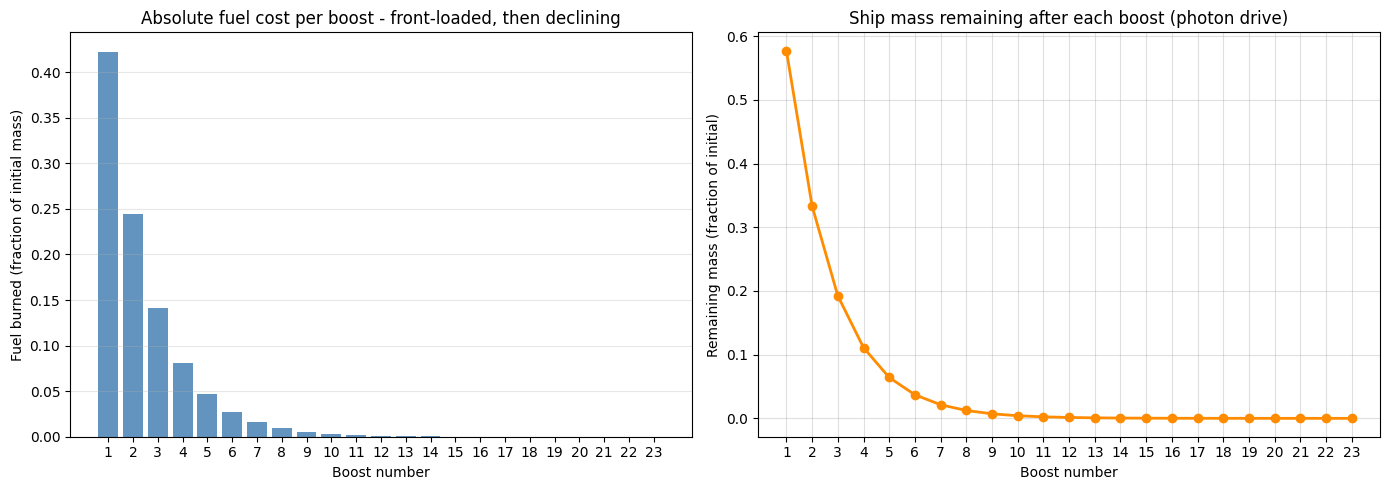

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: fuel burned per boost (absolute, normalised to initial mass = 1)
ax1.bar(boost_nums, fuel_each, color="steelblue", alpha=0.85)
ax1.set_xlabel("Boost number")
ax1.set_ylabel("Fuel burned (fraction of initial mass)")
ax1.set_title("Absolute fuel cost per boost - front-loaded, then declining")
ax1.grid(True, alpha=0.3, axis="y")
ax1.set_xticks(boost_nums)

# Right: remaining ship mass after each boost
remaining_after = [float(mass_ratio**n) for n in range(1, NUM_BUOYS + 1)]
ax2.plot(
    boost_nums, remaining_after, "o-", color="darkorange", linewidth=2, markersize=6
)
ax2.set_xlabel("Boost number")
ax2.set_ylabel("Remaining mass (fraction of initial)")
ax2.set_title("Ship mass remaining after each boost (photon drive)")
ax2.grid(True, alpha=0.4)
ax2.set_xticks(boost_nums)

plt.tight_layout()
plt.show();

## c is not a barrier

The most important thing to take from this scenario is what the crew *do not* experience.

At no point does the ship's behaviour change. Each boost is routine: check speed relative to the last buoy (zero), accelerate to $0.5c$, drop the next buoy. The crew feel the same thrust, reach the same relative speed, and repeat. The 23rd boost is indistinguishable from the 1st.

What changes is only how *other* frames describe the ship's motion:

- **Proper frame (crew)**: rapidity climbs at a constant rate. Each boost adds the same increment. This can continue indefinitely - there is no ceiling.
- **Earth's frame**: coordinate velocity asymptotically approaches $c$ but never reaches it. Each boost contributes a smaller and smaller increment to the coordinate speed.
- **Each buoy's frame**: the galaxy appears as an increasingly compressed disc. By buoy 23 it is a fraction of its rest-frame width.

The speed of light is not a wall. It is a limit that coordinate velocity asymptotically approaches from one side. Rapidity - the quantity that actually reflects what the crew experience - has no such limit. You can keep boosting forever.

---

*See also:*
[Rapidity](https://github.com/lookbusy1344/Relativity/blob/main/Python/Rapidity.ipynb) |
[Velocity adding](https://github.com/lookbusy1344/Relativity/blob/main/Python/Velocity%20adding.ipynb) |
[Time dilation](https://github.com/lookbusy1344/Relativity/blob/main/Python/Time%20dilation.ipynb)